In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report


In [5]:
ecg_df = pd.read_csv("/Users/nikitapatil/Documents/CardioSense-AI/data/mitdb/ecg_features.csv")
ecg_df.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,target,record
0,812.229938,26.346786,NaN,NaN,NaN,NaN,NaN,NaN,29.964768,30.178043,...,788.888889,833.333333,8.333333,51.388889,769.444444,880.555556,6.000000,93.7500,1,100
1,809.284627,24.927962,NaN,NaN,NaN,NaN,NaN,NaN,25.289815,25.467171,...,787.222222,830.555556,1.369863,42.465753,741.666667,863.888889,7.300000,117.1875,1,100
2,798.249619,23.563436,NaN,NaN,NaN,NaN,NaN,NaN,23.231332,23.393845,...,776.111111,819.444444,2.739726,35.616438,752.777778,847.222222,6.083333,31.2500,1,100
3,810.069444,34.548273,NaN,NaN,NaN,NaN,NaN,NaN,39.737554,40.017594,...,786.111111,838.888889,12.500000,48.611111,705.555556,897.222222,7.200000,148.4375,1,100
4,809.066358,29.544715,NaN,NaN,NaN,NaN,NaN,NaN,36.656232,36.917050,...,784.444444,830.000000,5.555556,40.277778,716.666667,888.888889,6.000000,109.3750,1,100


In [10]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Separate features and target
X = ecg_df.drop(columns=["target", "record"])
y = ecg_df["target"]

# DROP columns that are ALL NaN
X = X.dropna(axis=1, how="all")

print("Features after dropping all-NaN columns:", X.shape[1])
print("Dropped columns:", set(ecg_df.columns) - set(X.columns) - {"target", "record"})


Features after dropping all-NaN columns: 19
Dropped columns: {'HRV_SDANN1', 'HRV_SDNNI5', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDANN2', 'HRV_SDNNI1'}


In [16]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Recreate features cleanly
X = ecg_df.drop(columns=["target", "record"])

# 🔥 Drop all-NaN columns (again, safely)
X = X.dropna(axis=1, how="all")

# 🔥 Keep ONLY numeric columns (this is the missing step)
X = X.select_dtypes(include=["number"])

y = ecg_df["target"]

print("Final feature count:", X.shape[1])
print(X.dtypes)


Final feature count: 19
HRV_MeanNN      float64
HRV_SDNN        float64
HRV_RMSSD       float64
HRV_SDSD        float64
HRV_CVNN        float64
HRV_CVSD        float64
HRV_MedianNN    float64
HRV_MadNN       float64
HRV_MCVNN       float64
HRV_IQRNN       float64
HRV_SDRMSSD     float64
HRV_Prc20NN     float64
HRV_Prc80NN     float64
HRV_pNN50       float64
HRV_pNN20       float64
HRV_MinNN       float64
HRV_MaxNN       float64
HRV_HTI         float64
HRV_TINN        float64
dtype: object


In [17]:
imputer = SimpleImputer(strategy="median")

X_imputed_array = imputer.fit_transform(X)

X_imputed = pd.DataFrame(
    X_imputed_array,
    columns=X.columns,
    index=X.index
)

X_imputed.shape 

(150, 19)

In [18]:
X_imputed.isnull().sum().sum()

0

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Load ECG features
ecg_df = pd.read_csv("/Users/nikitapatil/Documents/CardioSense-AI/data/mitdb/ecg_features.csv")

# Build feature matrix
X = ecg_df.drop(columns=["target", "record"])

# Drop all-NaN columns
X = X.dropna(axis=1, how="all")

# Keep only numeric columns
X = X.select_dtypes(include=["number"])

y = ecg_df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

# Impute
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("After imputation:", X_imputed.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Features: (150, 19)
Target: (150,)
After imputation: (150, 19)
Train: (120, 19) Test: (30, 19)


In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Load ECG features
ecg_df = pd.read_csv("/Users/nikitapatil/Documents/CardioSense-AI/data/mitdb/ecg_features.csv")

print("Class distribution:")
print(ecg_df["target"].value_counts())

# Features / target
X = ecg_df.drop(columns=["target", "record"])

# Drop invalid HRV features
X = X.dropna(axis=1, how="all")

# Keep numeric only
X = X.select_dtypes(include=["number"])

y = ecg_df["target"]

# Impute
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Feature matrix shape:", X_imputed.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train class distribution:")
print(y_train.value_counts())


Class distribution:
target
1    240
0     30
Name: count, dtype: int64
Feature matrix shape: (270, 19)
Train class distribution:
target
1    192
0     24
Name: count, dtype: int64


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred = lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("Logistic Regression AUC-ROC:", auc)
print(classification_report(y_test, lr.predict(X_test)))


Logistic Regression AUC-ROC: 0.9965277777777778
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.96      1.00      0.98        48

    accuracy                           0.96        54
   macro avg       0.98      0.83      0.89        54
weighted avg       0.96      0.96      0.96        54



/Users/nikitapatil/CardioSense-AI/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
import shap

explainer = shap.Explainer(lr, X_train)
shap_values = explainer(X_test)


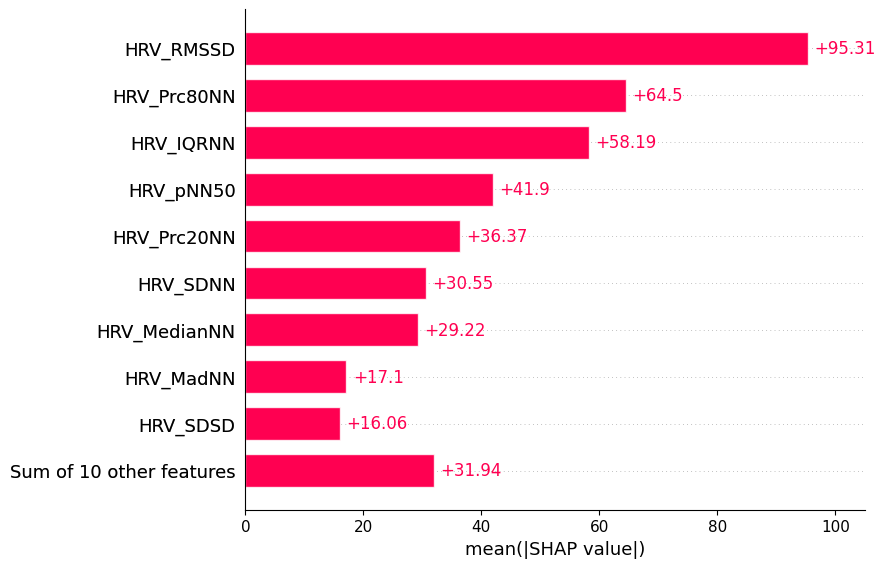

In [5]:
shap.plots.bar(shap_values, max_display=10)

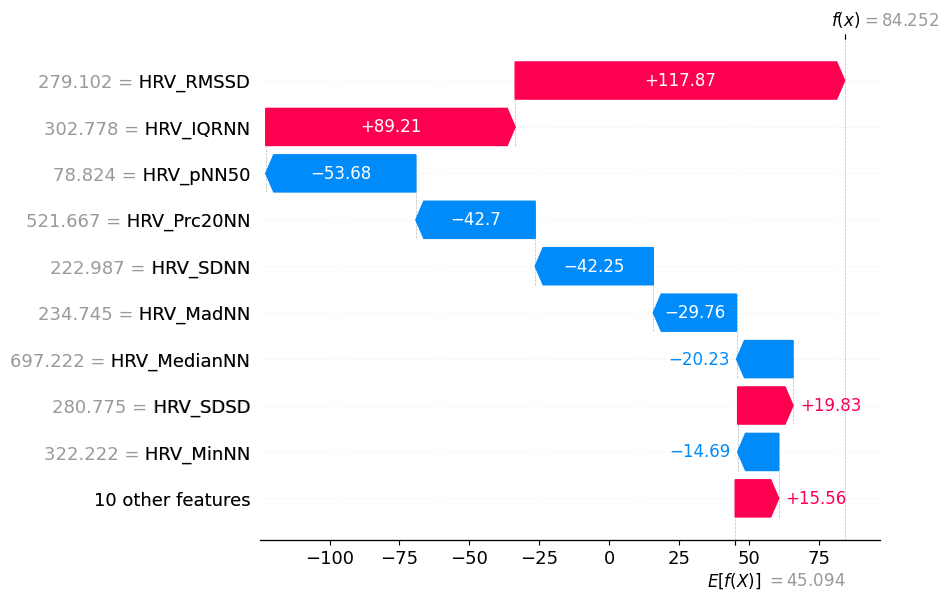

In [6]:
shap.plots.waterfall(shap_values[0])